### Task VI: Quantum Representation Learning with Contrastive Loss

This task involves implementing a simple representation learning scheme based on a contrastive loss. The goal is to train a quantum circuit to embed MNIST images such that images from the same class have high fidelity, and images from different classes have low fidelity.

**Implements:**
1.  **MNIST Loading**: Loading and preparing the MNIST dataset.
2.  **Trainable Quantum State Preparation**: A function that takes an image and prepares a quantum state with trainable parameters.
3.  **Two-Image SWAP Test Circuit**: A circuit that embeds two images as quantum states and performs a SWAP test to measure their fidelity.
4.  **Contrastive Training**: A training loop that maximizes fidelity for same-class images and minimizes it for different-class images.

In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 77.5 MB/s eta 0:00:00


In [3]:
import argparse
import os
import random
from dataclasses import dataclass

import numpy as np
import pennylane as qml
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [4]:
def set_seed(seed: int) -> None:
    """Sets the random seed for reproducibility across numpy, torch, and random modules."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# Set a default seed for consistent results
set_seed(42)

### MNIST Pair Dataset

The `MNISTPairDataset` class is a custom PyTorch `Dataset` that generates pairs of MNIST images. For each query image, it randomly selects another image which can either be from the same class (positive pair) or a different class (negative pair). This is crucial for contrastive learning, where we want to pull positive pairs closer and push negative pairs further apart in the learned representation space.

-   It loads the MNIST dataset and preprocesses images to `float` and normalizes them to `[0, 1]`.
-   `__getitem__` method samples `img_a`, `img_b`, and a `same_label` flag (1.0 for same class, 0.0 for different class).
-   It maintains `class_to_indices` to efficiently sample images from specific classes.

In [5]:
# -------------------------------
# MNIST pair dataset
# -------------------------------
class MNISTPairDataset(Dataset):
    """Samples random pairs of MNIST images and emits (img_a, img_b, same_label)."""

    def __init__(self, root: str, train: bool, max_samples: int | None = None):
        transform = transforms.ToTensor()
        base = datasets.MNIST(root=root, train=train, download=True, transform=transform)

        if max_samples is not None:
            indices = list(range(min(max_samples, len(base))))
            self.images = base.data[indices].float() / 255.0
            self.labels = base.targets[indices]
        else:
            self.images = base.data.float() / 255.0
            self.labels = base.targets

        self.class_to_indices = {}
        for idx, label in enumerate(self.labels.tolist()):
            self.class_to_indices.setdefault(label, []).append(idx)
        self.available_classes = sorted(self.class_to_indices.keys())

        self.num_items = len(self.images)

    def __len__(self):
        return self.num_items

    def __getitem__(self, idx):
        label_a = int(self.labels[idx].item())
        img_a = self.images[idx]

        same = bool(random.getrandbits(1))
        if same:
            idx_b = random.choice(self.class_to_indices[label_a])
            label_target = 1.0
        else:
            other_candidates = [c for c in self.available_classes if c != label_a]
            if not other_candidates:
                idx_b = random.choice(self.class_to_indices[label_a])
                label_target = 1.0
                img_b = self.images[idx_b]
                return img_a.unsqueeze(0), img_b.unsqueeze(0), torch.tensor(label_target, dtype=torch.float32)

            other_label = random.choice(other_candidates)
            idx_b = random.choice(self.class_to_indices[other_label])
            label_target = 0.0

        img_b = self.images[idx_b]
        return img_a.unsqueeze(0), img_b.unsqueeze(0), torch.tensor(label_target, dtype=torch.float32)

### Quantum Representation Model

The `QuantumContrastiveModel` is a PyTorch `nn.Module` that combines classical preprocessing with a quantum circuit to compute the fidelity between two image representations. It's designed to be trained end-to-end.

**`QuantumConfig`**: Defines the quantum circuit's architecture (number of qubits and layers).

**`QuantumContrastiveModel`**:
-   **`pre_net`**: A classical neural network (`nn.Sequential`) that flattens the 28x28 MNIST image, passes it through dense layers, and outputs a vector of size `2^n_qubits`. This vector is then normalized to be suitable for amplitude embedding.
-   **Quantum Circuit Setup**: Uses PennyLane to define a quantum device and a QNode (`swap_test_qnode`).
    -   `ancilla`: An auxiliary qubit used in the SWAP test.
    -   `wires_a`, `wires_b`: Qubits dedicated to embedding image A and image B, respectively.
-   **`_prepare_quantum_state`**: This function takes a preprocessed image vector and trainable parameters (`theta`) to prepare a quantum state. It uses `qml.AmplitudeEmbedding` to encode the classical vector into a quantum state and then applies `qml.StronglyEntanglingLayers` as a variational block with trainable weights (`theta`).
-   **`swap_test_qnode`**: This QNode implements the SWAP test. It prepares two quantum states from `vec_a` and `vec_b` using the shared `_prepare_quantum_state` function. A Hadamard gate is applied to the ancilla, followed by controlled-SWAP gates between the ancilla and corresponding qubits of `wires_a` and `wires_b`. Finally, another Hadamard on the ancilla completes the SWAP test. The probability of measuring the ancilla in the `|0>` state is related to the fidelity.
-   **`_encode_image`**: Preprocesses the input image through the `pre_net`, normalizes the output vector, and handles potential `NaN` values.
-   **`forward`**: Takes two images (`img_a`, `img_b`), encodes them into quantum-ready vectors, and then calls the `qnode` to compute the fidelity for each pair in the batch. The fidelity is derived from the probability of the ancilla being in state `|0>` after the SWAP test.

In [6]:
# -------------------------------
# Quantum representation model
# -------------------------------
@dataclass
class QuantumConfig:
    n_qubits: int = 4
    n_layers: int = 2


class QuantumContrastiveModel(nn.Module):
    """
    Shared trainable state-preparation + SWAP-test fidelity model.

    For each image:
      - Downsample to (2^n_qubits) features
      - Normalize to unit vector
      - Amplitude embedding + trainable variational block

    SWAP test outputs fidelity estimate F in [0,1].
    """

    def __init__(self, config: QuantumConfig):
        super().__init__()
        self.config = config
        self.n_features = 2 ** config.n_qubits

        self.pre_net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 64),
            nn.ReLU(),
            nn.Linear(64, self.n_features),
        )

        total_wires = 2 * config.n_qubits + 1
        self.ancilla = 0
        self.wires_a = list(range(1, 1 + config.n_qubits))
        self.wires_b = list(range(1 + config.n_qubits, 1 + 2 * config.n_qubits))

        self.dev = qml.device("default.qubit", wires=total_wires)

        # Initialize trainable parameters for the variational block
        init = 0.05 * torch.randn(config.n_layers, config.n_qubits, 3)
        self.theta = nn.Parameter(init)

        @qml.qnode(self.dev, interface="torch", diff_method="backprop")
        def swap_test_qnode(vec_a, vec_b, theta):
            self._prepare_quantum_state(vec_a, theta, self.wires_a)
            self._prepare_quantum_state(vec_b, theta, self.wires_b)

            qml.Hadamard(wires=self.ancilla)
            for wa, wb in zip(self.wires_a, self.wires_b):
                qml.CSWAP(wires=[self.ancilla, wa, wb])
            qml.Hadamard(wires=self.ancilla)

            return qml.probs(wires=self.ancilla)

        self.qnode = swap_test_qnode

    def _prepare_quantum_state(self, vec, theta, wires):
        qml.AmplitudeEmbedding(features=vec, wires=wires, normalize=True, pad_with=0.0)
        qml.StronglyEntanglingLayers(weights=theta, wires=wires)

    def _encode_image(self, x):
        vec = self.pre_net(x)
        vec = torch.nan_to_num(vec, nan=0.0, posinf=1.0, neginf=-1.0) # Handle potential NaNs
        vec = torch.tanh(vec) # Apply tanh to bring values to a reasonable range
        vec = F.normalize(vec, p=2, dim=-1, eps=1e-8) # Normalize to unit vector for amplitude embedding
        return vec

    def forward(self, img_a, img_b):
        va = self._encode_image(img_a)
        vb = self._encode_image(img_b)
        theta_safe = torch.nan_to_num(self.theta, nan=0.0, posinf=1.0, neginf=-1.0) # Ensure no NaNs in trainable params

        fidelities = []
        for i in range(va.shape[0]):
            probs = self.qnode(va[i], vb[i], theta_safe)
            p0 = probs[0] # Probability of ancilla being in |0> state
            fidelity = torch.clamp(2.0 * p0 - 1.0, 0.0, 1.0) # Convert probability to fidelity [0,1]
            fidelities.append(fidelity)

        return torch.stack(fidelities)

### Contrastive Loss

The `contrastive_fidelity_loss` function implements a custom contrastive loss. The objective is to:
-   **Maximize Fidelity (same_label=1)**: If two images are from the same class, their fidelity should be high. The term `(1.0 - fidelity)**2` penalizes low fidelity for same-class pairs, pushing `fidelity` towards 1.
-   **Minimize Fidelity (same_label=0)**: If two images are from different classes, their fidelity should be low. The term `fidelity**2` penalizes high fidelity for different-class pairs, pushing `fidelity` towards 0.

In [7]:
# -------------------------------
# Contrastive loss
# -------------------------------
def contrastive_fidelity_loss(fidelity, same_label):
    """
    same_label=1 -> maximize fidelity; same_label=0 -> minimize fidelity.
    This loss function is a variation of the contrastive loss.
    """
    # If same_label is 1, we want fidelity to be 1, so (1-fidelity)^2 goes to 0.
    # If same_label is 0, we want fidelity to be 0, so fidelity^2 goes to 0.
    return torch.mean(same_label * (1.0 - fidelity) ** 2 + (1.0 - same_label) * fidelity ** 2)

### Train / Evaluate Functions

These functions manage the training and evaluation loops of the model.

**`run_epoch`**:
-   Iterates through the data loader, computes fidelity, and calculates the contrastive loss.
-   If `optimizer` is provided (i.e., during training), it performs backpropagation, clips gradients to prevent exploding gradients, and updates model parameters.
-   It tracks the total loss, and the average fidelity for same-class and different-class pairs.
-   `torch.nan_to_num` is used to handle potential `NaN` values in gradients and model parameters, which can sometimes occur during quantum circuit training due to numerical instabilities.

**`save_curves`**:
-   Takes the training and validation history and plots the loss and fidelity curves over epochs.
-   This visualization helps in monitoring the training progress and identifying issues like overfitting or underfitting.

In [9]:
# -------------------------------
# Train / evaluate
# -------------------------------
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_same = 0.0
    total_diff = 0.0
    n_same = 0
    n_diff = 0

    for img_a, img_b, same_label in loader:
        if is_train:
            optimizer.zero_grad()

        fidelity = model(img_a, img_b)
        loss = contrastive_fidelity_loss(fidelity, same_label)

        if is_train:
            loss.backward()
            # Clip gradients to prevent explosion, common in quantum circuit training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            with torch.no_grad():
                # Ensure no NaNs propagate in parameters after update
                for param in model.parameters():
                    param.data = torch.nan_to_num(param.data, nan=0.0, posinf=1.0, neginf=-1.0)

        total_loss += loss.item() * img_a.size(0)

        # Track average fidelity for same-class and different-class pairs
        same_mask = same_label > 0.5
        diff_mask = ~same_mask
        if same_mask.any():
            total_same += fidelity[same_mask].mean().item()
            n_same += 1
        if diff_mask.any():
            total_diff += fidelity[diff_mask].mean().item()
            n_diff += 1

    mean_loss = total_loss / len(loader.dataset)
    mean_same_f = total_same / max(n_same, 1)
    mean_diff_f = total_diff / max(n_diff, 1)
    return mean_loss, mean_same_f, mean_diff_f


def save_curves(train_hist, val_hist, out_path):
    """Saves plots of training and validation loss/fidelity curves."""
    epochs = range(1, len(train_hist["loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(epochs, train_hist["loss"], label="Train loss")
    ax[0].plot(epochs, val_hist["loss"], label="Val loss")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Contrastive loss")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].plot(epochs, train_hist["same_f"], label="Train same-class fidelity")
    ax[1].plot(epochs, train_hist["diff_f"], label="Train diff-class fidelity")
    ax[1].plot(epochs, val_hist["same_f"], "--", label="Val same-class fidelity")
    ax[1].plot(epochs, val_hist["diff_f"], "--", label="Val diff-class fidelity")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Fidelity")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

### Main Execution Block

The `main` function orchestrates the entire training process:

-   **Argument Parsing**: It defines command-line arguments for various training parameters such as epochs, batch size, learning rate, number of qubits, number of layers, and dataset sizes. These are currently set to default values suitable for a Colab environment.
-   **Reproducibility**: Calls `set_seed` to ensure consistent results.
-   **Data Loading**: Initializes `MNISTPairDataset` for both training and validation, and then creates `DataLoader` instances for batching.
-   **Model and Optimizer Setup**: Instantiates `QuantumContrastiveModel` and the `Adam` optimizer.
-   **Training Loop**: Iterates for the specified number of epochs, calling `run_epoch` for both training and validation.
-   **Logging and Saving**: Prints progress after each epoch, saves the training curves as a PNG image, and saves the trained model's state dictionary along with training history and configuration to a checkpoint file.

In [10]:
# -------------------------------
# Main execution
# -------------------------------
def main():
    parser = argparse.ArgumentParser(description="Quantum contrastive representation learning on MNIST")
    parser.add_argument("--data-dir", default="data")
    parser.add_argument("--epochs", type=int, default=5)
    parser.add_argument("--batch-size", type=int, default=8)
    parser.add_argument("--lr", type=float, default=0.02)
    parser.add_argument("--n-qubits", type=int, default=4)
    parser.add_argument("--n-layers", type=int, default=2)
    parser.add_argument("--max-train", type=int, default=256) # Reduced for quicker Colab execution
    parser.add_argument("--max-val", type=int, default=128) # Reduced for quicker Colab execution
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--out-dir", default="outputs")

    # In a Colab environment, argparse tries to parse notebook-specific args.
    # We need to pass an empty list to parse_args() if running directly in a cell.
    # Otherwise, you can remove this `args = ...` line and use `args = parser.parse_args()`
    # if running as a script.
    args = parser.parse_args(args=[])

    set_seed(args.seed)
    os.makedirs(args.out_dir, exist_ok=True)

    train_ds = MNISTPairDataset(root=args.data_dir, train=True, max_samples=args.max_train)
    val_ds = MNISTPairDataset(root=args.data_dir, train=False, max_samples=args.max_val)

    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=args.batch_size, shuffle=False)

    model = QuantumContrastiveModel(QuantumConfig(n_qubits=args.n_qubits, n_layers=args.n_layers))
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

    train_hist = {"loss": [], "same_f": [], "diff_f": []}
    val_hist = {"loss": [], "same_f": [], "diff_f": []}

    print("Starting training...")
    for epoch in range(1, args.epochs + 1):
        tr_loss, tr_same, tr_diff = run_epoch(model, train_loader, optimizer)
        va_loss, va_same, va_diff = run_epoch(model, val_loader, optimizer=None)

        train_hist["loss"].append(tr_loss)
        train_hist["same_f"].append(tr_same)
        train_hist["diff_f"].append(tr_diff)

        val_hist["loss"].append(va_loss)
        val_hist["same_f"].append(va_same)
        val_hist["diff_f"].append(va_diff)

        print(
            f"Epoch {epoch:02d}/{args.epochs} | "
            f"train loss={tr_loss:.4f}, sameF={tr_same:.4f}, diffF={tr_diff:.4f} | "
            f"val loss={va_loss:.4f}, sameF={va_same:.4f}, diffF={va_diff:.4f}"
        )

    curves_path = os.path.join(args.out_dir, "training_curves.png")
    save_curves(train_hist, val_hist, curves_path)

    ckpt_path = os.path.join(args.out_dir, "quantum_contrastive_mnist.pt")
    torch.save(
        {
            "theta": model.theta.detach().cpu(),
            "pre_net": model.pre_net.state_dict(),
            "config": vars(args),
            "train_hist": train_hist,
            "val_hist": val_hist,
        },
        ckpt_path,
    )

    print("\nTraining complete!")
    print(f"- Curves saved to: {curves_path}")
    print(f"- Checkpoint saved to: {ckpt_path}")



### Run the Training

Execute the cell below to start the training process. The `main()` function will download the MNIST dataset (if not already present), set up the quantum model, train it for the specified number of epochs, and save the results.

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.05MB/s]


Starting training...
Epoch 01/5 | train loss=0.2093, sameF=0.7563, diffF=0.4805 | val loss=0.2105, sameF=0.7903, diffF=0.5313
Epoch 02/5 | train loss=0.2200, sameF=0.7676, diffF=0.5260 | val loss=0.2384, sameF=0.7895, diffF=0.5540
Epoch 03/5 | train loss=0.2252, sameF=0.7884, diffF=0.5081 | val loss=0.2627, sameF=0.8242, diffF=0.7141
Epoch 04/5 | train loss=0.2203, sameF=0.8595, diffF=0.5653 | val loss=0.2274, sameF=0.8158, diffF=0.5577
Epoch 05/5 | train loss=0.2144, sameF=0.7820, diffF=0.5292 | val loss=0.1544, sameF=0.8279, diffF=0.4275


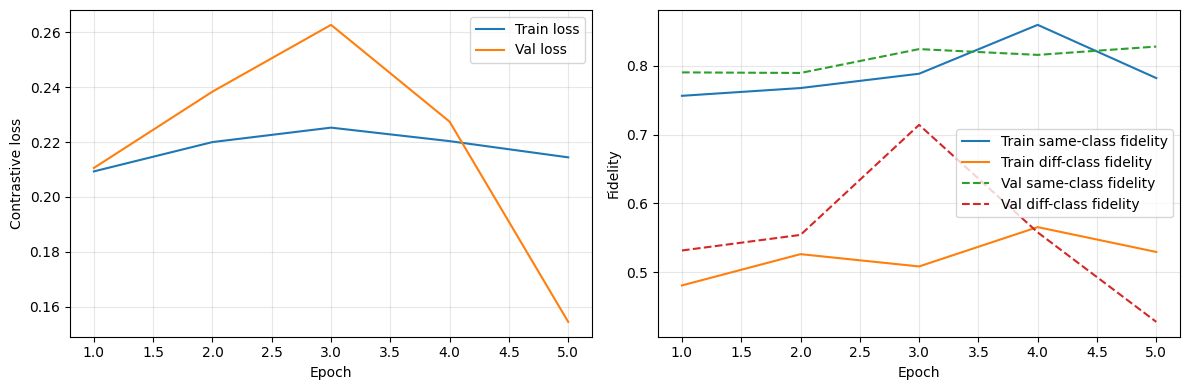


Training complete!
- Curves saved to: outputs/training_curves.png
- Checkpoint saved to: outputs/quantum_contrastive_mnist.pt


In [11]:
if __name__ == "__main__":
    main()